# Load Libraries

In [27]:
import os
import warnings
import logging
import sys
import pickle
import numpy as np
import pandas as pd
import geopandas as gpd
import dotenv
import pyet
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


# Load environment variables from .env file
dotenv.load_dotenv()

# Set up logging
logging.basicConfig(level=logging.INFO)

# Suppress warnings
warnings.filterwarnings("ignore")

# Set display options for pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_colwidth', None)

# Load Monthly Data

In [28]:
data = pd.read_parquet('../../data/Iran_Monthly_Data_1951_2025.parquet')
logging.info("Data loaded from parquet file.")

INFO:root:Data loaded from parquet file.


In [29]:
data

,year,month,region_id,region_name,station_id,station_name,lat,lon,station_elevation,tmax,tmax_count,tmin,tmin_count,tm,tm_count,umax,umax_count,umin,umin_count,um,um_count,ffm,ffm_count,sshn,sshn_count,pm,pm_count,p0m,p0m_count,ewm,ewm_count,radglo24,radglo24_count,td_m,td_m_count,twet_m,twet_m_count,tsoil_m,tsoil_m_count,ewsm,ewsm_count,evt,evt_count,rrr24,rrr24_count
0,1951,1,OIID,Airforce,40753,Dowshan Tappeh,35.70,51.48,1209.20,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,0.00,0,0.00,0
1,1951,2,OIID,Airforce,40753,Dowshan Tappeh,35.70,51.48,1209.20,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,0.00,0,0.00,0
2,1951,3,OIID,Airforce,40753,Dowshan Tappeh,35.70,51.48,1209.20,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,0.00,0,0.00,0
3,1951,4,OIID,Airforce,40753,Dowshan Tappeh,35.70,51.48,1209.20,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,0.00,0,0.00,0
4,1951,5,OIID,Airforce,40753,Dowshan Tappeh,35.70,51.48,1209.20,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,0.00,0,0.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
693376,2025,5,OITZ,Zanjan,18699,Zarrenrood,35.75,48.48,1751.00,24.46,13,12.53,10,19.07,10,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,0.00,0,12.20,11
693377,2025,6,OITZ,Zanjan,18699,Zarrenrood,35.75,48.48,1751.00,32.03,30,12.43,28,22.12,28,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,0.00,0,0.00,29
693378,2025,7,OITZ,Zanjan,18699,Zarrenrood,35.75,48.48,1751.00,36.54,31,17.80,30,27.14,30,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,0.00,0,3.10,30
693379,2025,8,OITZ,Zanjan,18699,Zarrenrood,35.75,48.48,1751.00,37.20,20,19.91,11,29.04,11,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,0.00,0,0.00,19


# Find Start and End Date

In [30]:
df = data[["region_id", "region_name", "station_name", "station_id", "year", "month", "lat", "lon", "station_elevation", "tm", "tm_count", "tmin", "tmin_count", "tmax", "tmax_count", "rrr24", "rrr24_count"]]

In [31]:
def days_in_month(year, month):
    if month == 2:
        if (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0):
            return 29
        else:
            return 28
    elif month in [4, 6, 9, 11]:
        return 30
    else:
        return 31

df['days_in_month'] = df.apply(lambda row: days_in_month(row['year'], row['month']), axis=1)

for col in df.columns:
    if col.endswith('_count'):
        percent_col = col.replace('_count', '_percent')
        df[percent_col] = round((df[col] / df['days_in_month']) * 100, 1)

In [32]:
df

,region_id,region_name,station_name,station_id,year,month,lat,lon,station_elevation,tm,tm_count,tmin,tmin_count,tmax,tmax_count,rrr24,rrr24_count,days_in_month,tm_percent,tmin_percent,tmax_percent,rrr24_percent
0,OIID,Airforce,Dowshan Tappeh,40753,1951,1,35.70,51.48,1209.20,NaN,0,NaN,0,NaN,0,0.00,0,31,0.00,0.00,0.00,0.00
1,OIID,Airforce,Dowshan Tappeh,40753,1951,2,35.70,51.48,1209.20,NaN,0,NaN,0,NaN,0,0.00,0,28,0.00,0.00,0.00,0.00
2,OIID,Airforce,Dowshan Tappeh,40753,1951,3,35.70,51.48,1209.20,NaN,0,NaN,0,NaN,0,0.00,0,31,0.00,0.00,0.00,0.00
3,OIID,Airforce,Dowshan Tappeh,40753,1951,4,35.70,51.48,1209.20,NaN,0,NaN,0,NaN,0,0.00,0,30,0.00,0.00,0.00,0.00
4,OIID,Airforce,Dowshan Tappeh,40753,1951,5,35.70,51.48,1209.20,NaN,0,NaN,0,NaN,0,0.00,0,31,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
693376,OITZ,Zanjan,Zarrenrood,18699,2025,5,35.75,48.48,1751.00,19.07,10,12.53,10,24.46,13,12.20,11,31,32.30,32.30,41.90,35.50
693377,OITZ,Zanjan,Zarrenrood,18699,2025,6,35.75,48.48,1751.00,22.12,28,12.43,28,32.03,30,0.00,29,30,93.30,93.30,100.00,96.70
693378,OITZ,Zanjan,Zarrenrood,18699,2025,7,35.75,48.48,1751.00,27.14,30,17.80,30,36.54,31,3.10,30,31,96.80,96.80,100.00,96.80
693379,OITZ,Zanjan,Zarrenrood,18699,2025,8,35.75,48.48,1751.00,29.04,11,19.91,11,37.20,20,0.00,19,31,35.50,35.50,64.50,61.30


In [33]:
for col in df.columns:
    if col.endswith('_percent'):
        df_75 = df[df[col] >= 75]

In [34]:
df_75

,region_id,region_name,station_name,station_id,year,month,lat,lon,station_elevation,tm,tm_count,tmin,tmin_count,tmax,tmax_count,rrr24,rrr24_count,days_in_month,tm_percent,tmin_percent,tmax_percent,rrr24_percent
255,OIID,Airforce,Dowshan Tappeh,40753,1972,4,35.70,51.48,1209.20,17.08,30,11.13,30,23.03,30,22.64,30,30,100.00,100.00,100.00,100.00
256,OIID,Airforce,Dowshan Tappeh,40753,1972,5,35.70,51.48,1209.20,18.24,31,12.45,31,24.03,31,56.24,31,31,100.00,100.00,100.00,100.00
257,OIID,Airforce,Dowshan Tappeh,40753,1972,6,35.70,51.48,1209.20,26.65,30,20.43,30,32.87,30,8.42,30,30,100.00,100.00,100.00,100.00
258,OIID,Airforce,Dowshan Tappeh,40753,1972,7,35.70,51.48,1209.20,29.65,31,23.16,31,36.13,31,2.00,31,31,100.00,100.00,100.00,100.00
259,OIID,Airforce,Dowshan Tappeh,40753,1972,8,35.70,51.48,1209.20,26.44,31,20.26,31,32.61,31,14.00,31,31,100.00,100.00,100.00,100.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
693373,OITZ,Zanjan,Zarrenrood,18699,2025,2,35.75,48.48,1751.00,-2.71,27,-8.84,27,3.43,27,32.20,26,28,96.40,96.40,96.40,92.90
693374,OITZ,Zanjan,Zarrenrood,18699,2025,3,35.75,48.48,1751.00,7.32,31,0.19,31,14.46,31,75.80,31,31,100.00,100.00,100.00,100.00
693375,OITZ,Zanjan,Zarrenrood,18699,2025,4,35.75,48.48,1751.00,13.23,30,6.31,30,20.16,30,49.60,30,30,100.00,100.00,100.00,100.00
693377,OITZ,Zanjan,Zarrenrood,18699,2025,6,35.75,48.48,1751.00,22.12,28,12.43,28,32.03,30,0.00,29,30,93.30,93.30,100.00,96.70


In [35]:
start_year = 2005
end_year = 2024
count_years = 19

df_75_selected_years = df_75[(df_75['year'] >= start_year) & (df_75['year'] <= end_year)]

selected_stations = df_75_selected_years.groupby(["region_id", "region_name", "station_name", "station_id"])["station_name"].count()\
    .sort_values(ascending=False)\
        .div(12)\
            .reset_index(name="count_years")\
                .query("count_years >= @count_years")

selected_data = df_75_selected_years.merge(selected_stations[["region_id", "region_name", "station_name", "station_id"]], on=["region_id", "region_name", "station_name", "station_id"], how="inner")

In [36]:
# Extract stations with at least 20 years of data
selected_data.groupby(["region_id", "region_name", "station_name", "station_id"])["station_name"].count()\
    .sort_values(ascending=False)\
        .div(12)\
            .reset_index(name="count_years")
                

,region_id,region_name,station_name,station_id,count_years
0,ALKK,Alborz,Karaj,40752,20.00
1,MAAA,Markazi,Arak,40769,20.00
2,MASA,Mazandaran,Gharakhil,40737,20.00
3,MAAA,Markazi,Delijan,99461,20.00
4,MAAA,Markazi,Khomeyn,99443,20.00
...,...,...,...,...,...
237,OISS,Fars,Jahrom,99646,19.00
238,OITT,Azarbayjan-E-Sharghi,Bostanabad,99248,19.00
239,OITR,Azarbayjan-E-Gharbi,Oshnavyeh,99288,19.00
240,OIZH,Sistan Va Baluchestan,Mirjaveh,99608,19.00


In [37]:
selected_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57798 entries, 0 to 57797
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   region_id          57798 non-null  object 
 1   region_name        57798 non-null  object 
 2   station_name       57798 non-null  object 
 3   station_id         57798 non-null  object 
 4   year               57798 non-null  int32  
 5   month              57798 non-null  int32  
 6   lat                57798 non-null  float64
 7   lon                57798 non-null  float64
 8   station_elevation  57798 non-null  float64
 9   tm                 57788 non-null  float64
 10  tm_count           57798 non-null  int64  
 11  tmin               57793 non-null  float64
 12  tmin_count         57798 non-null  int64  
 13  tmax               57788 non-null  float64
 14  tmax_count         57798 non-null  int64  
 15  rrr24              57798 non-null  float64
 16  rrr24_count        577

# Data Preparation and Long-Term Averages

In [38]:
# Calculate long-term mean for each station and month
clim = selected_data.groupby(["region_id", "region_name", "station_name", "station_id", "month"]).agg({'tm': 'mean', 'tmin': 'mean', 'tmax': 'mean', 'rrr24': 'sum'}).reset_index()
clim["delta"] = clim["tmax"] - clim["tmin"]

# Pivot the data so that each station has a single row with 12 months of tm and pr
clim_pivot = clim.pivot_table(index=["region_id", "region_name", "station_name", "station_id"], columns='month', values=['tm', 'tmin', 'tmax', 'delta', 'rrr24'])

# Flatten multi-index columns (tm, month) -> e.g. 'tm_1', 'pr_1', ..., 'tm_12', 'pr_12'
clim_pivot.columns = [f"{var}_{mon}" for var, mon in clim_pivot.columns]
clim_pivot = clim_pivot.reset_index()

# Merge with station metadata (lat, lon, elev)
stations_meta = selected_data[["region_id", "region_name", "station_name", "station_id", "lat", "lon", "station_elevation"]].drop_duplicates()
df_clim = pd.merge(clim_pivot, stations_meta, on=["region_id", "region_name", "station_name", "station_id"], how='left')

df_clim['tm_spring'] = df_clim[['tm_3', 'tm_4', 'tm_5']].mean(axis=1)
df_clim['tm_summer'] = df_clim[['tm_6', 'tm_7', 'tm_8']].mean(axis=1)
df_clim['tm_autumn'] = df_clim[['tm_9', 'tm_10', 'tm_11']].mean(axis=1)
df_clim['tm_winter'] = df_clim[['tm_12', 'tm_1', 'tm_2']].mean(axis=1)
df_clim['tm_annual'] = df_clim[[f'tm_{m}' for m in range(1, 13)]].mean(axis=1)
# df_clim['tm_annual_amplitude'] = df_clim[[f'tm_{m}' for m in range(1, 13)]].max(axis=1) - df_clim[[f'tm_{m}' for m in range(1, 13)]].min(axis=1)
# df_clim['tm_month_of_max'] = df_clim[[f'tm_{m}' for m in range(1, 13)]].idxmax(axis=1).str.split('_').str[1].astype(int)
# df_clim['tm_month_of_min'] = df_clim[[f'tm_{m}' for m in range(1, 13)]].idxmin(axis=1).str.split('_').str[1].astype(int)

df_clim['rrr24_spring'] = df_clim[['rrr24_3', 'rrr24_4', 'rrr24_5']].sum(axis=1)
df_clim['rrr24_summer'] = df_clim[['rrr24_6', 'rrr24_7', 'rrr24_8']].sum(axis=1)
df_clim['rrr24_autumn'] = df_clim[['rrr24_9', 'rrr24_10', 'rrr24_11']].sum(axis=1)
df_clim['rrr24_winter'] = df_clim[['rrr24_12', 'rrr24_1', 'rrr24_2']].sum(axis=1)
df_clim['rrr24_annual'] = df_clim[[f'rrr24_{m}' for m in range(1, 13)]].sum(axis=1)
# df_clim['rrr24_annual_amplitude'] = df_clim[[f'rrr24_{m}' for m in range(1, 13)]].max(axis=1) - df_clim[[f'rrr24_{m}' for m in range(1, 13)]].min(axis=1)
# df_clim['rrr24_month_of_max'] = df_clim[[f'rrr24_{m}' for m in range(1, 13)]].idxmax(axis=1).str.split('_').str[1].astype(int)
# df_clim['rrr24_month_of_min'] = df_clim[[f'rrr24_{m}' for m in range(1, 13)]].idxmin(axis=1).str.split('_').str[1].astype(int)

df_clim['delta_spring'] = df_clim[['delta_3', 'delta_4', 'delta_5']].mean(axis=1)
df_clim['delta_summer'] = df_clim[['delta_6', 'delta_7', 'delta_8']].mean(axis=1)
df_clim['delta_autumn'] = df_clim[['delta_9', 'delta_10', 'delta_11']].mean(axis=1)
df_clim['delta_winter'] = df_clim[['delta_12', 'delta_1', 'delta_2']].mean(axis=1)
df_clim['delta_annual'] = df_clim[[f'delta_{m}' for m in range(1, 13)]].mean(axis=1)

# df_clim now has one row per station with climate features and metadata
print(df_clim.columns.tolist())

['region_id', 'region_name', 'station_name', 'station_id', 'delta_1', 'delta_2', 'delta_3', 'delta_4', 'delta_5', 'delta_6', 'delta_7', 'delta_8', 'delta_9', 'delta_10', 'delta_11', 'delta_12', 'rrr24_1', 'rrr24_2', 'rrr24_3', 'rrr24_4', 'rrr24_5', 'rrr24_6', 'rrr24_7', 'rrr24_8', 'rrr24_9', 'rrr24_10', 'rrr24_11', 'rrr24_12', 'tm_1', 'tm_2', 'tm_3', 'tm_4', 'tm_5', 'tm_6', 'tm_7', 'tm_8', 'tm_9', 'tm_10', 'tm_11', 'tm_12', 'tmax_1', 'tmax_2', 'tmax_3', 'tmax_4', 'tmax_5', 'tmax_6', 'tmax_7', 'tmax_8', 'tmax_9', 'tmax_10', 'tmax_11', 'tmax_12', 'tmin_1', 'tmin_2', 'tmin_3', 'tmin_4', 'tmin_5', 'tmin_6', 'tmin_7', 'tmin_8', 'tmin_9', 'tmin_10', 'tmin_11', 'tmin_12', 'lat', 'lon', 'station_elevation', 'tm_spring', 'tm_summer', 'tm_autumn', 'tm_winter', 'tm_annual', 'rrr24_spring', 'rrr24_summer', 'rrr24_autumn', 'rrr24_winter', 'rrr24_annual', 'delta_spring', 'delta_summer', 'delta_autumn', 'delta_winter', 'delta_annual']


In [39]:
df_clim

,region_id,region_name,station_name,station_id,delta_1,delta_2,delta_3,delta_4,delta_5,delta_6,delta_7,delta_8,delta_9,delta_10,delta_11,delta_12,rrr24_1,rrr24_2,rrr24_3,rrr24_4,rrr24_5,rrr24_6,rrr24_7,rrr24_8,rrr24_9,rrr24_10,rrr24_11,rrr24_12,tm_1,tm_2,tm_3,tm_4,tm_5,tm_6,tm_7,tm_8,tm_9,tm_10,tm_11,tm_12,tmax_1,tmax_2,tmax_3,tmax_4,tmax_5,tmax_6,tmax_7,tmax_8,tmax_9,tmax_10,tmax_11,tmax_12,tmin_1,tmin_2,tmin_3,tmin_4,tmin_5,tmin_6,tmin_7,tmin_8,tmin_9,tmin_10,tmin_11,tmin_12,lat,lon,station_elevation,tm_spring,tm_summer,tm_autumn,tm_winter,tm_annual,rrr24_spring,rrr24_summer,rrr24_autumn,rrr24_winter,rrr24_annual,delta_spring,delta_summer,delta_autumn,delta_winter,delta_annual
0,ALKK,Alborz,Hashtgerd,99396,7.90,8.41,9.46,10.45,11.93,14.08,14.33,13.37,12.43,10.46,7.90,7.45,792.36,863.56,909.84,993.23,510.53,89.44,41.80,46.60,90.82,495.52,870.16,739.85,2.01,4.07,9.06,14.15,19.65,25.56,27.73,26.79,23.20,16.43,8.46,3.90,5.98,8.19,13.52,19.04,24.85,31.38,33.82,32.57,28.74,21.41,12.45,7.64,-1.92,-0.22,4.06,8.58,12.92,17.29,19.49,19.20,16.31,10.95,4.55,0.19,36.01,50.75,1612.90,14.28,26.69,16.03,3.33,15.08,2413.60,177.84,1456.50,2395.77,6443.71,10.61,13.93,10.26,7.92,10.68
1,ALKK,Alborz,Karaj,40752,9.21,9.95,11.38,12.72,14.43,16.33,16.44,15.75,15.03,12.77,9.75,9.18,612.80,710.89,712.35,799.96,393.26,77.33,53.56,57.92,61.02,408.11,666.89,556.92,3.03,5.25,10.55,15.51,20.58,26.21,28.38,27.27,23.50,17.13,9.50,5.01,7.74,10.29,16.18,21.80,27.63,34.11,36.47,35.04,31.06,23.78,14.64,9.83,-1.48,0.34,4.79,9.09,13.20,17.78,20.03,19.29,16.03,11.02,4.89,0.65,35.81,50.95,1292.90,15.55,27.29,16.71,4.43,15.99,1905.57,188.81,1136.02,1880.61,5111.01,12.84,16.17,12.51,9.45,12.75
2,MAAA,Markazi,Arak,40769,11.17,11.70,12.90,13.44,15.07,16.86,15.97,16.42,17.39,15.52,11.83,11.04,676.77,734.94,987.66,985.13,443.47,71.61,33.27,13.86,25.26,353.81,746.76,707.20,0.67,3.86,9.36,13.98,19.08,25.13,28.41,26.90,22.69,16.18,8.16,3.62,6.30,9.73,15.82,20.72,26.62,33.56,36.39,35.11,31.38,23.94,14.09,9.13,-4.88,-1.97,2.91,7.27,11.54,16.70,20.42,18.69,13.99,8.42,2.26,-1.91,34.07,49.78,1702.80,14.14,26.81,15.68,2.72,14.84,2416.26,118.74,1125.83,2118.91,5779.74,13.81,16.42,14.91,11.30,14.11
3,MAAA,Markazi,Delijan,99461,12.35,12.79,13.82,14.02,15.43,16.20,14.67,15.19,16.59,15.29,12.26,12.16,357.21,402.98,575.96,543.33,340.95,76.35,25.40,16.92,7.30,204.96,466.53,350.19,3.18,5.58,10.82,15.67,20.99,27.06,30.29,28.64,24.23,17.35,9.69,5.31,9.35,11.98,17.73,22.68,28.70,35.17,37.62,36.23,32.52,24.99,15.80,11.38,-3.00,-0.81,3.91,8.66,13.27,18.97,22.96,21.04,15.93,9.70,3.54,-0.78,33.98,50.69,1524.30,15.83,28.67,17.09,4.69,16.57,1460.24,118.67,678.79,1110.38,3368.08,14.42,15.35,14.72,12.43,14.23
4,MAAA,Markazi,Khomeyn,99443,11.54,11.75,12.69,13.59,15.47,18.20,17.39,17.78,18.04,15.62,11.97,11.81,636.60,716.31,814.91,805.60,342.91,90.10,22.60,19.10,37.01,307.20,799.41,754.11,1.18,3.92,8.72,13.05,17.86,23.72,27.20,25.60,21.68,15.49,8.11,3.69,6.95,9.79,15.08,19.85,25.59,32.82,35.89,34.49,30.70,23.29,14.09,9.59,-4.59,-1.96,2.39,6.26,10.12,14.62,18.50,16.71,12.66,7.67,2.12,-2.22,33.62,50.07,1834.60,13.21,25.51,15.09,2.93,14.18,1963.42,131.80,1143.62,2107.02,5345.86,13.92,17.79,15.21,11.70,14.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,OIZH,Sistan Va Baluchestan,Zahak,99623,14.33,14.92,15.89,16.29,16.01,14.95,13.78,13.70,15.48,16.37,15.43,15.08,245.35,180.77,225.63,140.23,66.94,6.50,33.00,0.00,0.00,1.71,62.12,67.25,10.64,14.50,21.11,26.91,32.61,36.43,37.83,35.75,31.61,25.31,17.41,11.73,16.60,20.71,27.40,33.02,38.22,41.66,43.00,41.01,37.55,31.74,23.80,18.11,2.27,5.78,11.51,16.72,22.21,26.72,29.22,27.31,22.07,15.37,8.37,3.03,30.90,61.68,495.00,26.88,36.67,24.77,12.29,25.15,432.80,39.50,63.83,493.37,1029.

# Data Preprocessing (Normalization & Scaling)

In [40]:
# Identify the climate feature columns
# temp_cols: all col start with tm_
temp_cols = [x for x in df_clim.columns if x.startswith('tm_')]
prec_cols = [x for x in df_clim.columns if x.startswith('rrr24_')]
delta_cols = [x for x in df_clim.columns if x.startswith('delta_')]
# temp_cols = [f"tm_{m}" for m in range(1, 13)]
# prec_cols = [f"rrr24_{m}" for m in range(1, 13)]
# temp_cols = [
#     "tm_spring",
#     "tm_summer",
#     "tm_autumn",
#     "tm_winter",
#     "tm_annual",
#     "tm_annual_amplitude",
# ]

# prec_cols = [
#     "rrr24_spring",
#     "rrr24_summer",
#     "rrr24_autumn",
#     "rrr24_winter",
#     "rrr24_annual",
#     "rrr24_annual_amplitude",
# ]
# temp_cols = [
#     "tm_spring",
# ]

# prec_cols = [
#     "rrr24_spring",
# ]

# Apply cube-root transform to precipitation columns to reduce skewness
for col in prec_cols:
    df_clim[col] = np.cbrt(df_clim[col])

# (Optional) If temperature distribution is highly skewed (usually not), one could transform temperature as well.
# Here we assume temperature values are roughly normal in distribution and just proceed to scaling.

# Prepare data for PCA: exclude non-climate columns
features = temp_cols + prec_cols + delta_cols + ['station_elevation']
# features = temp_cols + prec_cols
# features = ['tm_6', 'rrr24_6', 'station_elevation']
X = df_clim[features].values

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Principal Component Analysis (PCA)

In [41]:
from sklearn.decomposition import PCA

# Perform PCA without fixing components to examine variance explained
pca_full = PCA()
pca_full.fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Determine number of components to explain ~90% variance
num_components = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Cumulative variance by component: {cumulative_variance}")
print(f"Number of components needed for ~90% variance: {num_components}")

# Now apply PCA with the chosen number of components
pca = PCA(n_components=num_components)
X_reduced = pca.fit_transform(X_scaled)

# Show explained variance of each component
for i, var in enumerate(pca.explained_variance_ratio_, start=1):
    print(f"PC{i} explains {var*100:.1f}% of variance")


Cumulative variance by component: [0.43021819 0.7657726  0.88886618 0.9401655  0.96162054 0.97098525
 0.97771504 0.98343424 0.98625824 0.98889271 0.99078699 0.9921684
 0.99342469 0.99445595 0.99546394 0.99632104 0.99705852 0.99763571
 0.99815913 0.99848872 0.99879174 0.99906258 0.99927796 0.99944293
 0.999537   0.99961999 0.99969329 0.99975771 0.99980627 0.99984801
 0.99987706 0.99990304 0.99992349 0.99994259 0.99995978 0.99997247
 0.99998167 0.99998769 0.999992   0.99999519 0.99999821 1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.        ]
Number of components needed for ~90% variance: 4
PC1 explains 43.0% of variance
PC2 explains 33.6% of variance
PC3 explains 12.3% of variance
PC4 explains 5.1% of variance


# Clustering Stations into Climate Zones

In [42]:
from sklearn.cluster import KMeans

# Choose number of clusters (climate zones)
n_clusters = 5  # this can be changed to 7, 8, etc. as needed

# Perform K-Means clustering on the PCA-reduced climate data
kmeans = KMeans(n_clusters=n_clusters, n_init=20, random_state=0)
labels = kmeans.fit_predict(X_reduced)

# Add cluster labels to the dataframe
df_clim['cluster'] = labels

# View how many stations per cluster (as a quick sanity check)
print(df_clim['cluster'].value_counts())


cluster
3    88
2    62
0    48
1    30
4    14
Name: count, dtype: int64


In [43]:
from sklearn.cluster import AgglomerativeClustering
agg = AgglomerativeClustering(n_clusters=n_clusters)
labels_hier = agg.fit_predict(X_reduced)
df_clim['cluster_hier'] = labels_hier
print(df_clim['cluster_hier'].value_counts())

cluster_hier
0    105
1     74
3     30
2     22
4     11
Name: count, dtype: int64


# Visualization of Climate Zones on the Map

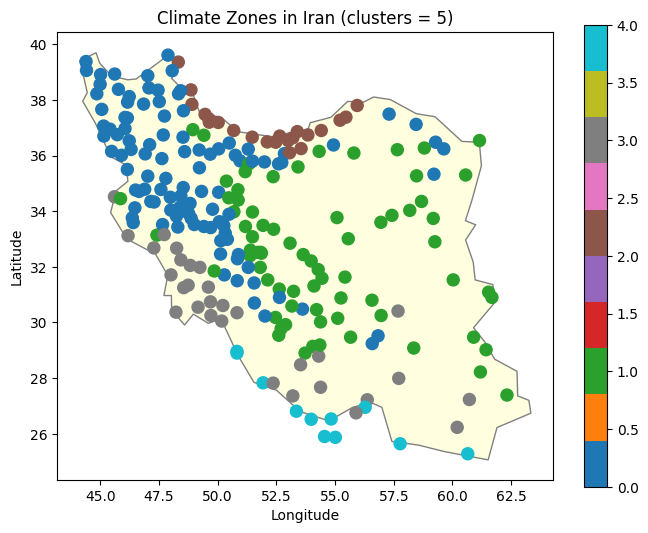

In [44]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Create a GeoDataFrame for stations using their lat/lon
gdf_stations = gpd.GeoDataFrame(
    df_clim, geometry=gpd.points_from_xy(df_clim['lon'], df_clim['lat']), crs="EPSG:4326"
)

# Load a world map and filter to Iran's boundary (using a built-in dataset for demonstration)
url = "../../data/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
iran = world[world['NAME'] == 'Iran']

# Plot the map
fig, ax = plt.subplots(figsize=(8,6))
iran.plot(ax=ax, color='lightyellow', edgecolor='gray')  # draw Iran country outline

# Plot stations, coloring by cluster
gdf_stations.plot(ax=ax, column='cluster_hier', cmap='tab10', markersize=75, legend=True)
ax.set_title(f"Climate Zones in Iran (clusters = {n_clusters})")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()


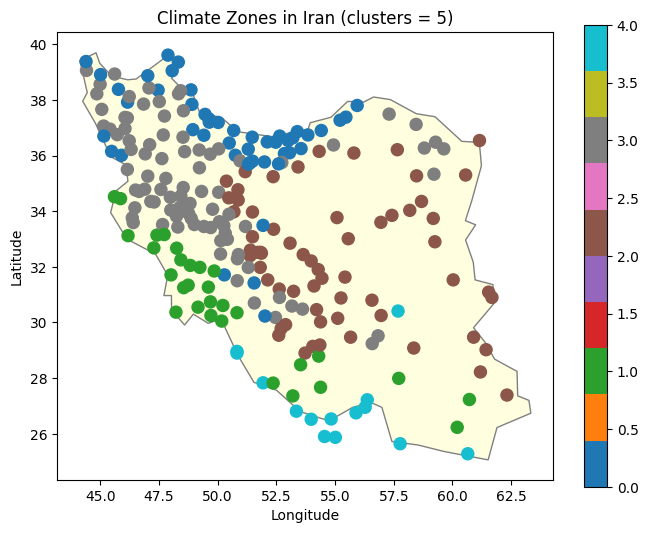

In [45]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Create a GeoDataFrame for stations using their lat/lon
gdf_stations = gpd.GeoDataFrame(
    df_clim, geometry=gpd.points_from_xy(df_clim['lon'], df_clim['lat']), crs="EPSG:4326"
)

# Load a world map and filter to Iran's boundary (using a built-in dataset for demonstration)
url = "../../data/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
iran = world[world['NAME'] == 'Iran']

# Plot the map
fig, ax = plt.subplots(figsize=(8,6))
iran.plot(ax=ax, color='lightyellow', edgecolor='gray')  # draw Iran country outline

# Plot stations, coloring by cluster
gdf_stations.plot(ax=ax, column='cluster', cmap='tab10', markersize=75, legend=True)
ax.set_title(f"Climate Zones in Iran (clusters = {n_clusters})")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()


In [46]:
import geopandas as gpd
import plotly.express as px
import plotly.graph_objects as go

# Create a GeoDataFrame for stations using their lat/lon
gdf_stations = gpd.GeoDataFrame(
    df_clim, geometry=gpd.points_from_xy(df_clim['lon'], df_clim['lat']), crs="EPSG:4326"
)

# Load a world map and filter to Iran
url = "../../data/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
iran = world[world['NAME'] == 'Iran']

# Convert Iran boundary to GeoJSON
iran_json = iran.__geo_interface__

# Create Plotly figure
fig = go.Figure()

# Add Iran map polygon
fig.add_trace(go.Choroplethmapbox(
    geojson=iran_json,
    locations=[0],  # single feature (Iran)
    z=[1],
    colorscale=[[0, 'lightyellow'], [1, 'lightyellow']],
    showscale=False,
    marker_line_width=0.8,
    marker_line_color='gray',
))

# Add station points (colored by cluster)
fig.add_trace(go.Scattermapbox(
    lat=gdf_stations['lat'],
    lon=gdf_stations['lon'],
    mode='markers',
    marker=dict(
        size=8,
        color=gdf_stations['cluster'],
        colorscale='spectral',
        showscale=True,
        colorbar=dict(title='Cluster')
    ),
    text=gdf_stations['station_name'],  # hover text
    hovertemplate=(
        "<b>%{text}</b><br>"
        "Cluster: %{marker.color}<br>"
        "Lat: %{lat:.2f}, Lon: %{lon:.2f}<extra></extra>"
    )
))

# Configure map layout
fig.update_layout(
    mapbox_style="carto-positron",
    mapbox_zoom=4.5,
    mapbox_center={"lat": 32.5, "lon": 54.0},
    margin={"r":0,"t":40,"l":0,"b":0},
    title=f"Climate Zones in Iran (clusters = {n_clusters})",
    height=900,  
    width=900,
)

fig.show()


In [47]:
import geopandas as gpd
import plotly.express as px
import plotly.graph_objects as go

# Create a GeoDataFrame for stations using their lat/lon
gdf_stations = gpd.GeoDataFrame(
    df_clim, geometry=gpd.points_from_xy(df_clim['lon'], df_clim['lat']), crs="EPSG:4326"
)

# Load a world map and filter to Iran
url = "../../data/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
iran = world[world['NAME'] == 'Iran']

# Convert Iran boundary to GeoJSON
iran_json = iran.__geo_interface__

# Create Plotly figure
fig = go.Figure()

# Add Iran map polygon
fig.add_trace(go.Choroplethmapbox(
    geojson=iran_json,
    locations=[0],  # single feature (Iran)
    z=[1],
    colorscale=[[0, 'lightyellow'], [1, 'lightyellow']],
    showscale=False,
    marker_line_width=0.8,
    marker_line_color='gray',
))

# Add station points (colored by cluster)
fig.add_trace(go.Scattermapbox(
    lat=gdf_stations['lat'],
    lon=gdf_stations['lon'],
    mode='markers',
    marker=dict(
        size=8,
        color=gdf_stations['cluster_hier'],
        colorscale='spectral',
        showscale=True,
        colorbar=dict(title='Cluster')
    ),
    text=gdf_stations['station_name'],  # hover text
    hovertemplate=(
        "<b>%{text}</b><br>"
        "Cluster: %{marker.color}<br>"
        "Lat: %{lat:.2f}, Lon: %{lon:.2f}<extra></extra>"
    )
))

# Configure map layout
fig.update_layout(
    mapbox_style="carto-positron",
    mapbox_zoom=4.5,
    mapbox_center={"lat": 32.5, "lon": 54.0},
    margin={"r":0,"t":40,"l":0,"b":0},
    title=f"Climate Zones in Iran (clusters = {n_clusters})",
    height=900,  
    width=900,
)

fig.show()


In [48]:
df_clim

,region_id,region_name,station_name,station_id,delta_1,delta_2,delta_3,delta_4,delta_5,delta_6,delta_7,delta_8,delta_9,delta_10,delta_11,delta_12,rrr24_1,rrr24_2,rrr24_3,rrr24_4,rrr24_5,rrr24_6,rrr24_7,rrr24_8,rrr24_9,rrr24_10,rrr24_11,rrr24_12,tm_1,tm_2,tm_3,tm_4,tm_5,tm_6,tm_7,tm_8,tm_9,tm_10,tm_11,tm_12,tmax_1,tmax_2,tmax_3,tmax_4,tmax_5,tmax_6,tmax_7,tmax_8,tmax_9,tmax_10,tmax_11,tmax_12,tmin_1,tmin_2,tmin_3,tmin_4,tmin_5,tmin_6,tmin_7,tmin_8,tmin_9,tmin_10,tmin_11,tmin_12,lat,lon,station_elevation,tm_spring,tm_summer,tm_autumn,tm_winter,tm_annual,rrr24_spring,rrr24_summer,rrr24_autumn,rrr24_winter,rrr24_annual,delta_spring,delta_summer,delta_autumn,delta_winter,delta_annual,cluster,cluster_hier
0,ALKK,Alborz,Hashtgerd,99396,7.90,8.41,9.46,10.45,11.93,14.08,14.33,13.37,12.43,10.46,7.90,7.45,9.25,9.52,9.69,9.98,7.99,4.47,3.47,3.60,4.49,7.91,9.55,9.04,2.01,4.07,9.06,14.15,19.65,25.56,27.73,26.79,23.20,16.43,8.46,3.90,5.98,8.19,13.52,19.04,24.85,31.38,33.82,32.57,28.74,21.41,12.45,7.64,-1.92,-0.22,4.06,8.58,12.92,17.29,19.49,19.20,16.31,10.95,4.55,0.19,36.01,50.75,1612.90,14.28,26.69,16.03,3.33,15.08,13.41,5.62,11.34,13.38,18.61,10.61,13.93,10.26,7.92,10.68,0,0
1,ALKK,Alborz,Karaj,40752,9.21,9.95,11.38,12.72,14.43,16.33,16.44,15.75,15.03,12.77,9.75,9.18,8.49,8.92,8.93,9.28,7.33,4.26,3.77,3.87,3.94,7.42,8.74,8.23,3.03,5.25,10.55,15.51,20.58,26.21,28.38,27.27,23.50,17.13,9.50,5.01,7.74,10.29,16.18,21.80,27.63,34.11,36.47,35.04,31.06,23.78,14.64,9.83,-1.48,0.34,4.79,9.09,13.20,17.78,20.03,19.29,16.03,11.02,4.89,0.65,35.81,50.95,1292.90,15.55,27.29,16.71,4.43,15.99,12.40,5.74,10.43,12.34,17.23,12.84,16.17,12.51,9.45,12.75,3,0
2,MAAA,Markazi,Arak,40769,11.17,11.70,12.90,13.44,15.07,16.86,15.97,16.42,17.39,15.52,11.83,11.04,8.78,9.02,9.96,9.95,7.63,4.15,3.22,2.40,2.93,7.07,9.07,8.91,0.67,3.86,9.36,13.98,19.08,25.13,28.41,26.90,22.69,16.18,8.16,3.62,6.30,9.73,15.82,20.72,26.62,33.56,36.39,35.11,31.38,23.94,14.09,9.13,-4.88,-1.97,2.91,7.27,11.54,16.70,20.42,18.69,13.99,8.42,2.26,-1.91,34.07,49.78,1702.80,14.14,26.81,15.68,2.72,14.84,13.42,4.92,10.40,12.84,17.95,13.81,16.42,14.91,11.30,14.11,3,0
3,MAAA,Markazi,Delijan,99461,12.35,12.79,13.82,14.02,15.43,16.20,14.67,15.19,16.59,15.29,12.26,12.16,7.10,7.39,8.32,8.16,6.99,4.24,2.94,2.57,1.94,5.90,7.76,7.05,3.18,5.58,10.82,15.67,20.99,27.06,30.29,28.64,24.23,17.35,9.69,5.31,9.35,11.98,17.73,22.68,28.70,35.17,37.62,36.23,32.52,24.99,15.80,11.38,-3.00,-0.81,3.91,8.66,13.27,18.97,22.96,21.04,15.93,9.70,3.54,-0.78,33.98,50.69,1524.30,15.83,28.67,17.09,4.69,16.57,11.35,4.91,8.79,10.36,14.99,14.42,15.35,14.72,12.43,14.23,2,1
4,MAAA,Markazi,Khomeyn,99443,11.54,11.75,12.69,13.59,15.47,18.20,17.39,17.78,18.04,15.62,11.97,11.81,8.60,8.95,9.34,9.30,7.00,4.48,2.83,2.67,3.33,6.75,9.28,9.10,1.18,3.92,8.72,13.05,17.86,23.72,27.20,25.60,21.68,15.49,8.11,3.69,6.95,9.79,15.08,19.85,25.59,32.82,35.89,34.49,30.70,23.29,14.09,9.59,-4.59,-1.96,2.39,6.26,10.12,14.62,18.50,16.71,12.66,7.67,2.12,-2.22,33.62,50.07,1834.60,13.21,25.51,15.09,2.93,14.18,12.52,5.09,10.46,12.82,17.49,13.92,17.79,15.21,11.70,14.65,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,OIZH,Sistan Va Baluchestan,Zahak,99623,14.33,14.92,15.89,16.29,16.01,14.95,13.78,13.70,15.48,16.37,15.43,15.08,6.26,5.65,6.09,5.20,4.06,1.87,3.21,0.00,0.00,1.20,3.96,4.07,10.64,14.50,21.11,26.91,32.61,36.43,37.83,35.75,31.61,25.31,17.41,11.73,16.60,20.71,27.40,33.02,38.22,41.66,43.00,41.01,37.55,31.74,23.80,18.11,2.27,5.78,11.51,16.72,22.21,26.72,29.22,27.31,22.07,15.37,8.37,3.03,30.90,61.68,495.00,26.88,36.67,24.77,12.29,25.15,7.56,3.41,4.00,7.90,10.10,16.06,14.14,15.76,14.78,15.19,2,1
238,OIZH,Sistan Va Baluchestan,Zahedan,40856,14.65,14.30,14.29,15.14,15.60,16.22,16

In [49]:
dd = pd.wide_to_long(
    df_clim,
    stubnames=['tm', 'rrr24'],
    i=['region_id', 'station_id', 'region_name', 'station_name'],
    j='month',
    sep='_'
).reset_index()
dd

,region_id,station_id,region_name,station_name,month,cluster,cluster_hier,delta_1,delta_10,delta_11,delta_12,delta_2,delta_3,delta_4,delta_5,delta_6,delta_7,delta_8,delta_9,delta_annual,delta_autumn,delta_spring,delta_summer,delta_winter,lat,lon,rrr24_annual,rrr24_autumn,rrr24_spring,rrr24_summer,rrr24_winter,station_elevation,tm_annual,tm_autumn,tm_spring,tm_summer,tm_winter,tmax_1,tmax_10,tmax_11,tmax_12,tmax_2,tmax_3,tmax_4,tmax_5,tmax_6,tmax_7,tmax_8,tmax_9,tmin_1,tmin_10,tmin_11,tmin_12,tmin_2,tmin_3,tmin_4,tmin_5,tmin_6,tmin_7,tmin_8,tmin_9,tm,rrr24
0,ALKK,99396,Alborz,Hashtgerd,1,0,0,7.90,10.46,7.90,7.45,8.41,9.46,10.45,11.93,14.08,14.33,13.37,12.43,10.68,10.26,10.61,13.93,7.92,36.01,50.75,18.61,11.34,13.41,5.62,13.38,1612.90,15.08,16.03,14.28,26.69,3.33,5.98,21.41,12.45,7.64,8.19,13.52,19.04,24.85,31.38,33.82,32.57,28.74,-1.92,10.95,4.55,0.19,-0.22,4.06,8.58,12.92,17.29,19.49,19.20,16.31,2.01,9.25
1,ALKK,99396,Alborz,Hashtgerd,2,0,0,7.90,10.46,7.90,7.45,8.41,9.46,10.45,11.93,14.08,14.33,13.37,12.43,10.68,10.26,10.61,13.93,7.92,36.01,50.75,18.61,11.34,13.41,5.62,13.38,1612.90,15.08,16.03,14.28,26.69,3.33,5.98,21.41,12.45,7.64,8.19,13.52,19.04,24.85,31.38,33.82,32.57,28.74,-1.92,10.95,4.55,0.19,-0.22,4.06,8.58,12.92,17.29,19.49,19.20,16.31,4.07,9.52
2,ALKK,99396,Alborz,Hashtgerd,3,0,0,7.90,10.46,7.90,7.45,8.41,9.46,10.45,11.93,14.08,14.33,13.37,12.43,10.68,10.26,10.61,13.93,7.92,36.01,50.75,18.61,11.34,13.41,5.62,13.38,1612.90,15.08,16.03,14.28,26.69,3.33,5.98,21.41,12.45,7.64,8.19,13.52,19.04,24.85,31.38,33.82,32.57,28.74,-1.92,10.95,4.55,0.19,-0.22,4.06,8.58,12.92,17.29,19.49,19.20,16.31,9.06,9.69
3,ALKK,99396,Alborz,Hashtgerd,4,0,0,7.90,10.46,7.90,7.45,8.41,9.46,10.45,11.93,14.08,14.33,13.37,12.43,10.68,10.26,10.61,13.93,7.92,36.01,50.75,18.61,11.34,13.41,5.62,13.38,1612.90,15.08,16.03,14.28,26.69,3.33,5.98,21.41,12.45,7.64,8.19,13.52,19.04,24.85,31.38,33.82,32.57,28.74,-1.92,10.95,4.55,0.19,-0.22,4.06,8.58,12.92,17.29,19.49,19.20,16.31,14.15,9.98
4,ALKK,99396,Alborz,Hashtgerd,5,0,0,7.90,10.46,7.90,7.45,8.41,9.46,10.45,11.93,14.08,14.33,13.37,12.43,10.68,10.26,10.61,13.93,7.92,36.01,50.75,18.61,11.34,13.41,5.62,13.38,1612.90,15.08,16.03,14.28,26.69,3.33,5.98,21.41,12.45,7.64,8.19,13.52,19.04,24.85,31.38,33.82,32.57,28.74,-1.92,10.95,4.55,0.19,-0.22,4.06,8.58,12.92,17.29,19.49,19.20,16.31,19.65,7.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2899,QOQM,40887,Qom,Salafchegan,8,2,1,9.29,11.57,9.45,9.14,9.84,10.97,11.70,12.96,13.42,12.57,12.73,12.88,11.38,11.30,11.88,12.91,9.42,34.48,50.47,14.84,8.72,10.84,4.13,10.81,1381.40,17.78,18.36,17.39,30.00,5.36,8.88,24.46,15.39,10.56,11.49,17.57,22.89,28.95,34.92,37.06,35.44,31.63,-0.41,12.89,5.94,1.43,1.65,6.61,11.19,15.99,21.50,24.49,22.71,18.74,29.63,1.77
2900,QOQM,40887,Qom,Salafchegan,9,2,1,9.29,11.57,9.45,9.14,9.84,10.97,11.70,12.96,13.42,12.57,12.73,12.88,11.38,11.30,11.88,12.91,9.42,34.48,50.47,14.84,8.72,10.84,4.13,10.81,1381.40,17.78,18.36,17.39,30.00,5.36,8.88,24.46,15.39,10.56,11.49,17.57,22.89,28.95,34.92,37.06,35.44,31.63,-0.41,12.89,5.94,1.43,1.65,6.61,11.19,15.99,21.50,24.49,22.71,18.74,25.66,2.77
2901,QOQM,40887,Qom,Salafchegan,10,2,1,9.29,11.57,9.45,9.14,9.84,10.97,11.70,12.96,13.42,12.57,12.73,12.88,11.38,11.30,11.88,12.91,9.42,34.48,50.47,14.84,8.72,10.84,4.13,10.81,1381.40,17.78,18.36,17.39,30.00,5.36,8.88,24.46,15.39,10.56,11.49,17.57,22.89,28.95,34.92,37.06,35.44,31.63,-0.41,12.89,5.94,1.43,1.65,6.61,11.19,15.99,21.50,24.49,22.71,18.74,18.92,5.02
2902,QOQM,40887,Qom,Salafchegan,11,2,1,9.29,11.57,9.45,9.14,9.84,10.97,11.70,12.96,13.42,12.57,12.73,12.88,11.38,11.30,11.88,12.91,9.42,34.48,50.47,14.84,8.72,10.84,4.13,10.81,1381.40,17.78,18.36,17.39,30.00,5.36,8.88,24.46,15.39,10.56,11.49,17.57,22.89,28.95,34.92,37.06,35.44,31.63,-0.41,12.89,5.94,1.43,1.

In [50]:
dd.describe()

,month,cluster,cluster_hier,delta_1,delta_10,delta_11,delta_12,delta_2,delta_3,delta_4,delta_5,delta_6,delta_7,delta_8,delta_9,delta_annual,delta_autumn,delta_spring,delta_summer,delta_winter,lat,lon,rrr24_annual,rrr24_autumn,rrr24_spring,rrr24_summer,rrr24_winter,station_elevation,tm_annual,tm_autumn,tm_spring,tm_summer,tm_winter,tmax_1,tmax_10,tmax_11,tmax_12,tmax_2,tmax_3,tmax_4,tmax_5,tmax_6,tmax_7,tmax_8,tmax_9,tmin_1,tmin_10,tmin_11,tmin_12,tmin_2,tmin_3,tmin_4,tmin_5,tmin_6,tmin_7,tmin_8,tmin_9,tm,rrr24
count,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00,2904.00
mean,6.50,1.96,1.04,10.85,13.90,11.58,11.13,11.02,11.97,12.79,13.83,15.10,14.45,14.75,15.11,13.04,13.53,12.86,14.77,11.00,33.65,51.51,17.48,10.41,12.07,5.41,12.66,1150.74,17.79,18.68,17.19,28.58,6.71,10.67,25.86,17.72,12.91,12.97,18.00,23.18,28.84,34.40,36.43,35.58,32.13,-0.18,11.95,6.14,1.78,1.95,6.03,10.39,15.00,19.30,21.98,20.83,17.02,17.79,6.71
std,3.45,1.23,1.20,2.36,3.53,2.67,2.66,2.35,2.56,2.62,3.03,3.76,3.76,3.75,4.08,2.92,3.34,2.70,3.74,2.43,3.32,4.18,4.27,3.64,2.65,3.20,2.95,707.54,5.06,5.08,5.40,4.77,5.52,5.64,5.27,5.45,5.46,5.63,5.42,5.53,5.74,5.24,4.93,4.73,4.88,5.84,5.66,5.59,5.57,5.57,5.24,5.40,5.79,5.62,5.11,5.22,5.53,9.97,3.35
min,1.00,0.00,0.00,4.93,5.38,5.13,5.03,4.84,5.30,5.41,5.60,4.32,3.02,3.11,4.08,5.20,5.18,5.48,3.54,5.00,25.28,44.39,8.54,3.72,6.09,0.00,7.00,-23.60,5.70,6.71,4.24,16.71,-4.85,-2.92,10.46,2.82,-0.63,-2.25,2.14,7.49,13.03,19.11,22.22,20.83,17.21,-11.18,2.11,-2.89,-7.55,-8.35,-4.35,0.57,5.22,8.61,11.63,10.13,6.01,-5.88,0.00
25%,3.75,1.00,0.00,9.31,11.54,9.61,9.37,9.44,10.21,11.14,12.02,13.18,12.35,12.70,12.70,11.24,11.31,11.21,12.81,9.42,31.27,48.33,14.33,7.81,9.88,3.30,10.57,591.10,13.99,15.08,12.98,25.38,2.66,6.30,22.18,13.85,8.83,9.02,14.13,19.09,24.76,30.84,33.08,32.57,28.86,-4.15,7.77,2.14,-2.09,-1.96,2.26,6.38,10.35,14.80,18.15,16.94,12.66,9.43,3.94
50%,6.50,2.00,1.00,10.91,14.29,11.81,10.96,11.08,12.16,13.14,14.26,15.47,15.07,15.15,15.65,13.34,13.95,13.14,15.34,10.97,33.97,50.86,17.27,10.45,12.53,4.55,12.33,1303.50,16.95,17.97,15.91,27.79,5.72,10.12,24.89,16.71,11.90,12.06,16.76,21.80,27.71,34.00,36.41,35.21,31.66,-1.25,10.85,4.81,0.45,0.93,5.04,9.24,14.08,18.80,21.56,20.46,16.40,18.08,7.05
75%,9.25,3.00,2.00,12.29,16.67,13.38,12.90,12.57,13.76,14.82,15.96,17.69,16.96,17.42,18.18,15.31,16.14,14.86,17.23,12.63,36.27,54.10,19.79,11.94,14.07,6.80,14.40,1633.00,20.68,20.81,20.38,32.02,9.13,13.87,28.79,20.17,15.57,16.56,21.45,27.00,33.23,37.27,38.97,37.93,34.87,2.85,14.75,8.64,4.54,4.39,8.15,13.07,18.27,23.14,25.01,23.84,20.22,25.81,9.11
max,12.00,4.00,4.00,16.30,21.06,17.77,17.98,16.47,17.18,17.79,19.90,23.59,23.50,23.35,24.05,19.11,20.23,17.99,23.48,16.62,39.61,62.32,32.80,25.83,20.33,16.74,22.75,2985.70,29.49,30.59,31.38,39.30,21.91,24.50,37.34,30.72,26.59,26.50,31.07,36.69,41.78,46.12,47.70,47.35,43.95,18.45,28.43,24.55,20.75,18.94,21.35,24.60,28.90,32.91,34.01,33.05,30.86,40.13,18.63


In [51]:
dd

,region_id,station_id,region_name,station_name,month,cluster,cluster_hier,delta_1,delta_10,delta_11,delta_12,delta_2,delta_3,delta_4,delta_5,delta_6,delta_7,delta_8,delta_9,delta_annual,delta_autumn,delta_spring,delta_summer,delta_winter,lat,lon,rrr24_annual,rrr24_autumn,rrr24_spring,rrr24_summer,rrr24_winter,station_elevation,tm_annual,tm_autumn,tm_spring,tm_summer,tm_winter,tmax_1,tmax_10,tmax_11,tmax_12,tmax_2,tmax_3,tmax_4,tmax_5,tmax_6,tmax_7,tmax_8,tmax_9,tmin_1,tmin_10,tmin_11,tmin_12,tmin_2,tmin_3,tmin_4,tmin_5,tmin_6,tmin_7,tmin_8,tmin_9,tm,rrr24
0,ALKK,99396,Alborz,Hashtgerd,1,0,0,7.90,10.46,7.90,7.45,8.41,9.46,10.45,11.93,14.08,14.33,13.37,12.43,10.68,10.26,10.61,13.93,7.92,36.01,50.75,18.61,11.34,13.41,5.62,13.38,1612.90,15.08,16.03,14.28,26.69,3.33,5.98,21.41,12.45,7.64,8.19,13.52,19.04,24.85,31.38,33.82,32.57,28.74,-1.92,10.95,4.55,0.19,-0.22,4.06,8.58,12.92,17.29,19.49,19.20,16.31,2.01,9.25
1,ALKK,99396,Alborz,Hashtgerd,2,0,0,7.90,10.46,7.90,7.45,8.41,9.46,10.45,11.93,14.08,14.33,13.37,12.43,10.68,10.26,10.61,13.93,7.92,36.01,50.75,18.61,11.34,13.41,5.62,13.38,1612.90,15.08,16.03,14.28,26.69,3.33,5.98,21.41,12.45,7.64,8.19,13.52,19.04,24.85,31.38,33.82,32.57,28.74,-1.92,10.95,4.55,0.19,-0.22,4.06,8.58,12.92,17.29,19.49,19.20,16.31,4.07,9.52
2,ALKK,99396,Alborz,Hashtgerd,3,0,0,7.90,10.46,7.90,7.45,8.41,9.46,10.45,11.93,14.08,14.33,13.37,12.43,10.68,10.26,10.61,13.93,7.92,36.01,50.75,18.61,11.34,13.41,5.62,13.38,1612.90,15.08,16.03,14.28,26.69,3.33,5.98,21.41,12.45,7.64,8.19,13.52,19.04,24.85,31.38,33.82,32.57,28.74,-1.92,10.95,4.55,0.19,-0.22,4.06,8.58,12.92,17.29,19.49,19.20,16.31,9.06,9.69
3,ALKK,99396,Alborz,Hashtgerd,4,0,0,7.90,10.46,7.90,7.45,8.41,9.46,10.45,11.93,14.08,14.33,13.37,12.43,10.68,10.26,10.61,13.93,7.92,36.01,50.75,18.61,11.34,13.41,5.62,13.38,1612.90,15.08,16.03,14.28,26.69,3.33,5.98,21.41,12.45,7.64,8.19,13.52,19.04,24.85,31.38,33.82,32.57,28.74,-1.92,10.95,4.55,0.19,-0.22,4.06,8.58,12.92,17.29,19.49,19.20,16.31,14.15,9.98
4,ALKK,99396,Alborz,Hashtgerd,5,0,0,7.90,10.46,7.90,7.45,8.41,9.46,10.45,11.93,14.08,14.33,13.37,12.43,10.68,10.26,10.61,13.93,7.92,36.01,50.75,18.61,11.34,13.41,5.62,13.38,1612.90,15.08,16.03,14.28,26.69,3.33,5.98,21.41,12.45,7.64,8.19,13.52,19.04,24.85,31.38,33.82,32.57,28.74,-1.92,10.95,4.55,0.19,-0.22,4.06,8.58,12.92,17.29,19.49,19.20,16.31,19.65,7.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2899,QOQM,40887,Qom,Salafchegan,8,2,1,9.29,11.57,9.45,9.14,9.84,10.97,11.70,12.96,13.42,12.57,12.73,12.88,11.38,11.30,11.88,12.91,9.42,34.48,50.47,14.84,8.72,10.84,4.13,10.81,1381.40,17.78,18.36,17.39,30.00,5.36,8.88,24.46,15.39,10.56,11.49,17.57,22.89,28.95,34.92,37.06,35.44,31.63,-0.41,12.89,5.94,1.43,1.65,6.61,11.19,15.99,21.50,24.49,22.71,18.74,29.63,1.77
2900,QOQM,40887,Qom,Salafchegan,9,2,1,9.29,11.57,9.45,9.14,9.84,10.97,11.70,12.96,13.42,12.57,12.73,12.88,11.38,11.30,11.88,12.91,9.42,34.48,50.47,14.84,8.72,10.84,4.13,10.81,1381.40,17.78,18.36,17.39,30.00,5.36,8.88,24.46,15.39,10.56,11.49,17.57,22.89,28.95,34.92,37.06,35.44,31.63,-0.41,12.89,5.94,1.43,1.65,6.61,11.19,15.99,21.50,24.49,22.71,18.74,25.66,2.77
2901,QOQM,40887,Qom,Salafchegan,10,2,1,9.29,11.57,9.45,9.14,9.84,10.97,11.70,12.96,13.42,12.57,12.73,12.88,11.38,11.30,11.88,12.91,9.42,34.48,50.47,14.84,8.72,10.84,4.13,10.81,1381.40,17.78,18.36,17.39,30.00,5.36,8.88,24.46,15.39,10.56,11.49,17.57,22.89,28.95,34.92,37.06,35.44,31.63,-0.41,12.89,5.94,1.43,1.65,6.61,11.19,15.99,21.50,24.49,22.71,18.74,18.92,5.02
2902,QOQM,40887,Qom,Salafchegan,11,2,1,9.29,11.57,9.45,9.14,9.84,10.97,11.70,12.96,13.42,12.57,12.73,12.88,11.38,11.30,11.88,12.91,9.42,34.48,50.47,14.84,8.72,10.84,4.13,10.81,1381.40,17.78,18.36,17.39,30.00,5.36,8.88,24.46,15.39,10.56,11.49,17.57,22.89,28.95,34.92,37.06,35.44,31.63,-0.41,12.89,5.94,1.43,1.

In [52]:
st = "40732"

# plot scatter plot of temperature vs precipitation for a specific station with plotly
a = dd[dd["station_id"] == st][["region_name", "station_name", "station_id", "month", "tm", "rrr24"]]

# now drow line from month 1 to 12 for each point
fig = px.scatter(
    a,
    x='tm',
    y='rrr24',
    title=f'{a.region_name.unique()[0]} - {a.station_name.unique()[0]} ({st})',
    labels={'tm': 'Mean Monthly Temperature (°C)', 'rrr24': 'Mean Monthly Precipitation (mm)'},
    width=600,
    height=600,
)
fig.add_trace(go.Scatter(
    x=a['tm'],
    y=a['rrr24'],
    mode='lines+markers',
    line=dict(color='LightSkyBlue', width=2),
    marker=dict(size=8),
    name='Monthly Trend'
)) 
# show month number on each point
for i, row in a.iterrows():
    fig.add_annotation(
        x=row['tm'],
        y=row['rrr24'],
        text=str(int(row['month'])),
        showarrow=True,
        arrowhead=1,
        ax=10,
        ay=-10
    ) 

# x: -10 to 45 and y: 0 to 10
fig.update_xaxes(range=[-10, 45])
fig.update_yaxes(range=[0, 20])

# no legend
fig.update_layout(showlegend=False)

# x and y grid lines for each 1 unit
fig.update_xaxes(dtick=5, showgrid=True, gridwidth=1, gridcolor='LightGray')
fig.update_yaxes(dtick=2, showgrid=True, gridwidth=1, gridcolor='LightGray')